# CS 483 FairLend Miners
## K-Means Clustering and Disparate-Impact Audit
**Author:** Het Nagda  
**Input:** `hmda_chicago_2023_cleaned.parquet`
**Outputs:** clustered parquet, per-cluster DIR audit CSV, summary plot.

Pipeline: load cleaned data -> financial-feature EDA -> optimal-k selection (elbow + silhouette) -> PySpark MLlib K-Means -> per-cluster denial-rate audit by demographic group -> DIR vs the 0.8 fair-lending threshold.

In [1]:
!pip install pyspark --quiet

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR   = '/content/drive/MyDrive/CS483_Fairlend_Miners'
os.makedirs(PROJECT_DIR, exist_ok=True)

CLEANED_PATH = f'{PROJECT_DIR}/hmda_chicago_2023_cleaned.parquet'
METADATA_PATH = f'{PROJECT_DIR}/pipeline_metadata.json'
CLUSTER_OUT = f'{PROJECT_DIR}/hmda_chicago_2023_clustered.parquet'
AUDIT_OUT = f'{PROJECT_DIR}/disparate_impact_audit.csv'

print(f'Project dir : {PROJECT_DIR}')
print(f'Input file : {CLEANED_PATH}')
print(f'File exists : {os.path.exists(CLEANED_PATH)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir : /content/drive/MyDrive/CS483_Fairlend_Miners
Input file  : /content/drive/MyDrive/CS483_Fairlend_Miners/hmda_chicago_2023_cleaned.parquet
File exists : True


## 1. Load Cleaned Data

In [3]:
clean_df = pd.read_parquet(CLEANED_PATH)
clean_df['denied_flag'] = (clean_df['denied'] == 1).astype(int)

total = len(clean_df)
denied = int(clean_df['denied_flag'].sum())
originated = total - denied

print(f'Total loans: {total:,}')
print(f'Originated: {originated:,} ({originated/total*100:.1f}%)')
print(f'Denied: {denied:,} ({denied/total*100:.1f}%)')
print(f'Columns: {list(clean_df.columns)}')

Total loans: 103,481
Originated: 78,760 (76.1%)
Denied: 24,721 (23.9%)
Columns: ['action_taken', 'denied', 'derived_race', 'derived_sex', 'derived_ethnicity', 'applicant_age', 'income', 'loan_amount', 'interest_rate', 'combined_loan_to_value_ratio', 'loan_term', 'dti_numeric', 'loan_type', 'loan_purpose', 'occupancy_type', 'lien_status', 'derived_dwelling_category', 'county_code', 'census_tract', 'denied_flag']


## 2. Financial-Feature EDA

Audited denial rates against demographic and binned features. This Section Profiles the raw numeric features used for clustering: income, loan amount, DTI, and CLTV.

In [4]:
FEATURES = ['income', 'loan_amount', 'dti_numeric', 'combined_loan_to_value_ratio']
FEATURES = [f for f in FEATURES if f in clean_df.columns]
stats = clean_df[FEATURES].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(2)
print('FINANCIAL FEATURE SUMMARY')
print(stats.to_string())
print('\nNULL COUNTS')
print(clean_df[FEATURES].isna().sum().to_string())

FINANCIAL FEATURE SUMMARY
          income  loan_amount  dti_numeric  combined_loan_to_value_ratio
count  103481.00    103481.00    100585.00                      99866.00
mean      136.13    241844.73        40.62                         80.81
std       110.81    209568.44        13.12                        442.75
min        16.00      5000.00        10.00                          0.02
5%         41.00     25000.00        25.00                         31.25
25%        71.00    105000.00        33.00                         69.38
50%       103.00    205000.00        41.00                         80.00
75%       161.00    315000.00        48.00                         95.00
95%       342.00    605000.00        70.00                        100.00
max      1025.00   5105000.00        70.00                      81613.24

NULL COUNTS
income                             0
loan_amount                        0
dti_numeric                     2896
combined_loan_to_value_ratio    3615


In [5]:
denied_mean = clean_df.loc[clean_df['denied_flag']==1, FEATURES].mean()
originated_mean = clean_df.loc[clean_df['denied_flag']==0, FEATURES].mean()
diff_pct = ((denied_mean - originated_mean) / originated_mean * 100).round(1)
compare = pd.DataFrame({
    'originated_avg': originated_mean.round(2),
    'denied_avg': denied_mean.round(2),
    'diff_%': diff_pct
})
print('FEATURE MEANS: ORIGINATED vs DENIED')
print(compare.to_string())

FEATURE MEANS: ORIGINATED vs DENIED
                              originated_avg  denied_avg  diff_%
income                                144.05      110.91   -23.0
loan_amount                        267498.98   160111.44   -40.1
dti_numeric                            38.09       48.75    28.0
combined_loan_to_value_ratio           78.37       88.70    13.2


## 3. Build Modeling Frame by dropping null

K-Means cannot handle nulls. Drop incomplete rows once, before sending to Spark, so cluster labels can be merged back onto the original DataFrame by row index.

In [6]:
model_df = clean_df.dropna(subset=FEATURES).reset_index(drop=True).copy()

if 'combined_loan_to_value_ratio' in FEATURES:
    model_df['combined_loan_to_value_ratio'] = model_df['combined_loan_to_value_ratio'].clip(upper=200)

model_df['row_id'] = np.arange(len(model_df))

dropped = total - len(model_df)
frame_denial_rate = model_df['denied_flag'].mean()
full_denial_rate  = clean_df['denied_flag'].mean()

print(f'Rows kept: {len(model_df):,}')
print(f'Rows dropped: {dropped:,} ({dropped/total*100:.2f}% had null in {FEATURES})')
print(f'Denied in modeling frame: {int(model_df["denied_flag"].sum()):,} '
      f'({frame_denial_rate*100:.1f}%)')
print(f'Denied in full sample: {int(clean_df["denied_flag"].sum()):,} '
      f'({full_denial_rate*100:.1f}%)')

assert frame_denial_rate > 0.5 * full_denial_rate, (
    f'Modeling frame lost too many denials: {frame_denial_rate:.1%} vs full {full_denial_rate:.1%}. '
    f'A feature in {FEATURES} likely correlates with the outcome.'
)

Rows kept: 99,524
Rows dropped: 3,957 (3.82% had null in ['income', 'loan_amount', 'dti_numeric', 'combined_loan_to_value_ratio'])
Denied in modeling frame: 23,382 (23.5%)
Denied in full sample: 24,721 (23.9%)


## 4. Spark Session

In [18]:
spark = (SparkSession.builder
         .appName('FairLend_KMeans')
         .config('spark.driver.memory', '8g')
         .config('spark.sql.shuffle.partitions', '8')
         .getOrCreate())
spark.sparkContext.setLogLevel('ERROR')

sdf = spark.createDataFrame(model_df[FEATURES + ['row_id']])
print(f'Spark version : {spark.version}')
print(f'Spark rows : {sdf.count():,}')

Spark version : 4.0.2
Spark rows : 99,524


## 5. Feature Vector and Standardization

Income, loan amount, DTI, and CLTV live on very different scales. Without standardization, K-Means is dominated by income and loan amount. We z-score using `StandardScaler` before clustering.

In [8]:
assembler = VectorAssembler(
    inputCols=FEATURES,
    outputCol='features_raw',
    handleInvalid='error'
)
sdf_vec = assembler.transform(sdf)

scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withMean=True,
    withStd=True
)
scaler_model = scaler.fit(sdf_vec)
sdf_scaled = scaler_model.transform(sdf_vec).select('row_id', 'features')

print(f'Vectorized rows: {sdf_scaled.count():,}')
sdf_scaled.show(3, truncate=80)

Vectorized rows: 99,524
+------+--------------------------------------------------------------------------------+
|row_id|                                                                        features|
+------+--------------------------------------------------------------------------------+
|     0|[0.42775468280379514,-0.4189650616817715,2.2463084224281165,0.48440967391276035]|
|     1|  [2.578205593184839,0.4483227676803943,-0.19711125243234226,1.0680124979361827]|
|     2|[1.302514375162186,-0.7562436619892805,-0.5788955766292889,-0.016767886133120...|
+------+--------------------------------------------------------------------------------+
only showing top 3 rows


## 6. Optimal-k Selection
Silhouette peaks at k=2 here but two clusters is too coarse for a meaningful audit. Enforced k≥4.

In [9]:
K_RANGE = range(2, 9)
K_FLOOR = 4

evaluator = ClusteringEvaluator(featuresCol='features', predictionCol='cluster', metricName='silhouette')

metrics = []
for k in K_RANGE:
    km   = KMeans(featuresCol='features', predictionCol='cluster', k=k, seed=42, maxIter=30)
    mdl  = km.fit(sdf_scaled)
    pred = mdl.transform(sdf_scaled)
    wcss = mdl.summary.trainingCost
    sil  = evaluator.evaluate(pred)
    metrics.append({'k': k, 'wcss': wcss, 'silhouette': sil})
    print(f'k={k} | WCSS={wcss:>14,.0f} | silhouette={sil:.4f}')

metrics_df = pd.DataFrame(metrics)

candidates = metrics_df[metrics_df['k'] >= K_FLOOR]
best_k = int(candidates.loc[candidates['silhouette'].idxmax(), 'k'])
print(f'\nSelected k = {best_k} (silhouette-optimal under k>={K_FLOOR})')

k=2 | WCSS=       300,965 | silhouette=0.5904
k=3 | WCSS=       235,336 | silhouette=0.4749
k=4 | WCSS=       200,088 | silhouette=0.3546
k=5 | WCSS=       175,597 | silhouette=0.4176
k=6 | WCSS=       155,723 | silhouette=0.4085
k=7 | WCSS=       140,604 | silhouette=0.3971
k=8 | WCSS=       130,595 | silhouette=0.3796

Selected k = 5 (silhouette-optimal under k>=4)


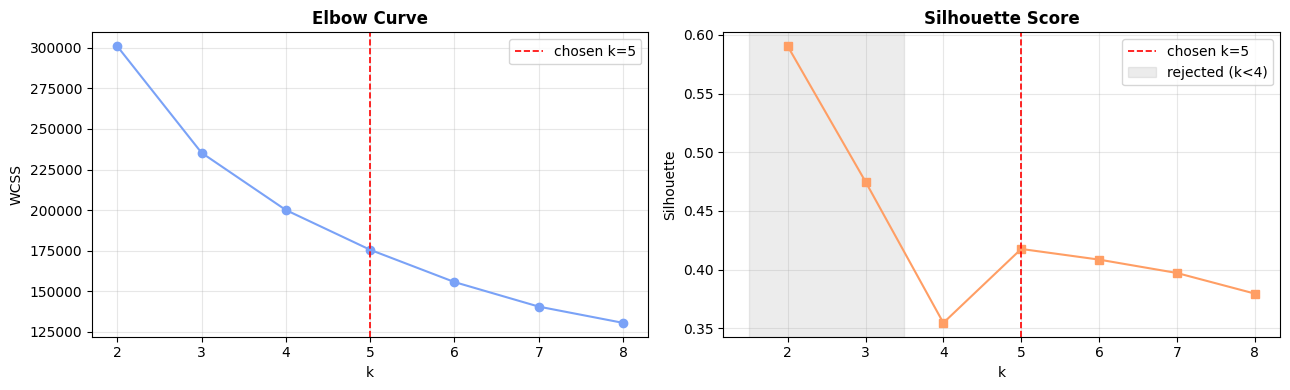

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(metrics_df['k'], metrics_df['wcss'], marker='o', color='#7aa2f7')
ax[0].axvline(best_k, color='red', ls='--', lw=1.2, label=f'chosen k={best_k}')
ax[0].set_xlabel('k')
ax[0].set_ylabel('WCSS')
ax[0].set_title('Elbow Curve', fontweight='bold')
ax[0].grid(alpha=0.3)
ax[0].legend()
ax[1].plot(metrics_df['k'], metrics_df['silhouette'], marker='s', color='#ff9e64')
ax[1].axvline(best_k, color='red', ls='--', lw=1.2, label=f'chosen k={best_k}')
ax[1].axvspan(K_RANGE.start - 0.5, K_FLOOR - 0.5, color='gray', alpha=0.15, label=f'rejected (k<{K_FLOOR})')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Silhouette')
ax[1].set_title('Silhouette Score', fontweight='bold')
ax[1].grid(alpha=0.3)
ax[1].legend()
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/memberC_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Fit Final K-Means and Join Labels Back

Pull only (row_id, cluster) from Spark and merge onto model_df.

In [11]:
final_km = KMeans(featuresCol='features', predictionCol='cluster', k=best_k, seed=42, maxIter=50)
final_model = final_km.fit(sdf_scaled)
predictions = final_model.transform(sdf_scaled).select('row_id', 'cluster')

labels = predictions.toPandas()
clustered = model_df.merge(labels, on='row_id', how='left')
assert clustered['cluster'].isna().sum() == 0, 'Cluster join lost rows'

print(f'Final WCSS: {final_model.summary.trainingCost:,.0f}')
print(f'Final silhouette: {evaluator.evaluate(final_model.transform(sdf_scaled)):.4f}')
print(f'Cluster sizes:')
print(clustered['cluster'].value_counts().sort_index().to_string())

Final WCSS: 175,597
Final silhouette: 0.4178
Cluster sizes:
cluster
0    48783
1    20223
2    11314
3    15680
4     3524


In [12]:
profile = (clustered.groupby('cluster')
           .agg(size=('row_id', 'count'),
                denial_rate=('denied_flag', 'mean'),
                avg_income_K=('income', 'mean'),
                avg_loan_K=('loan_amount', 'mean'),
                avg_dti=('dti_numeric', 'mean'),
                avg_cltv=('combined_loan_to_value_ratio', 'mean'))
           .round(2))
profile['denial_rate%'] = (profile['denial_rate'] * 100).round(1)
profile = profile.drop(columns='denial_rate')

print('CLUSTER PROFILE')
print(profile.to_string())

CLUSTER PROFILE
          size  avg_income_K  avg_loan_K  avg_dti  avg_cltv  denial_rate%
cluster                                                                  
0        48783         94.91   205911.79    41.70     88.80          17.0
1        20223        224.83   373430.50    31.42     80.49          10.0
2        11314         80.07   150110.48    63.60     70.01          79.0
3        15680        103.84   115718.75    34.54     42.73          24.0
4         3524        519.26   842928.49    30.61     75.40          11.0


## 8. Disparate-Impact Audit

Per cluster, denial and acceptance rates are computed for each demographic group. The **Disparate Impact Ratio (DIR)** is the standard EEOC selection-rate formulation:

$$DIR_g = \frac{\text{acceptance rate of group } g}{\text{acceptance rate of the reference group}}$$

where acceptance rate equals one minus denial rate.

Reference group: **White** for race, **Male** for sex, **Not Hispanic or Latino** for ethnicity. Under the four-fifths rule from U.S. fair-lending enforcement, DIR < 0.80 indicates disparate impact: the protected group is accepted at less than 80% of the reference group's rate.

In [13]:
DEMOGRAPHICS = {
    'race': ('derived_race', 'White'),
    'sex': ('derived_sex', 'Male'),
    'ethnicity': ('derived_ethnicity','Not Hispanic or Latino'),
}
MIN_GROUP_SIZE = 30
DIR_THRESHOLD = 0.8

def audit_attribute(df, attr_col, reference_value):
    out = []
    for c in sorted(df['cluster'].unique()):
        sub = df[df['cluster'] == c]
        ref = sub[sub[attr_col] == reference_value]
        if len(ref) < MIN_GROUP_SIZE:
            continue
        ref_denial = ref['denied_flag'].mean()
        ref_accept = 1 - ref_denial
        for g, gdf in sub.groupby(attr_col):
            if len(gdf) < MIN_GROUP_SIZE or g == reference_value:
                continue
            grp_denial = gdf['denied_flag'].mean()
            grp_accept = 1 - grp_denial
            if ref_accept == 0:
                dir_ratio = np.nan
                flag = 'ref_zero_acceptance'
            else:
                dir_ratio = grp_accept / ref_accept
                if dir_ratio < DIR_THRESHOLD:
                    flag = 'DISPARATE_IMPACT'
                else:
                    flag = 'ok'
            out.append({
                'cluster' : int(c),
                'attribute' : attr_col,
                'reference' : reference_value,
                'group': g,
                'cluster_size' : len(sub),
                'group_size' : len(gdf),
                'ref_size' : len(ref),
                'group_denial%' : round(grp_denial*100, 2),
                'ref_denial%' : round(ref_denial*100, 2),
                'group_accept%' : round(grp_accept*100, 2),
                'ref_accept%': round(ref_accept*100, 2),
                'DIR' : None if pd.isna(dir_ratio) else round(dir_ratio, 3),
                'flag': flag,
            })
    return pd.DataFrame(out)

audits = []
for label, (col, ref) in DEMOGRAPHICS.items():
    if col in clustered.columns:
        audits.append(audit_attribute(clustered, col, ref))
audit_df = pd.concat(audits, ignore_index=True)

print(f'Audit rows : {len(audit_df):,}')
print(f'Disparate-impact flags : {(audit_df["flag"]=="DISPARATE_IMPACT").sum()}')
print(f'Zero-acceptance reference clusters (excluded) : '
      f'{(audit_df["flag"]=="ref_zero_acceptance").sum()}')

Audit rows : 45
Disparate-impact flags : 10
Zero-acceptance reference clusters (excluded) : 0


In [14]:
scoped = audit_df[audit_df['flag'] != 'ref_zero_acceptance'].copy()
print('TOP DISPARATE-IMPACT FINDINGS (lowest DIR first)')
top = scoped.sort_values('DIR').head(15)
cols = ['cluster','attribute','group','reference', 'group_denial%','ref_denial%','DIR','flag','group_size','ref_size']
print(top[cols].to_string(index=False))
print('\nDIR SUMMARY BY ATTRIBUTE (audited clusters only)')
summary = (scoped.groupby('attribute')['DIR']
           .agg(['count','mean','min','max'])
           .round(3))
print(summary.to_string())

TOP DISPARATE-IMPACT FINDINGS (lowest DIR first)
 cluster         attribute                                     group              reference  group_denial%  ref_denial%   DIR             flag  group_size  ref_size
       2      derived_race Native Hawaiian or Other Pacific Islander                  White          94.12        76.81 0.254 DISPARATE_IMPACT          34      7526
       3      derived_race                  2 or more minority races                  White          51.52        20.32 0.608 DISPARATE_IMPACT          33     12029
       3      derived_race Native Hawaiian or Other Pacific Islander                  White          51.35        20.32 0.611 DISPARATE_IMPACT          37     12029
       2      derived_race                  2 or more minority races                  White          85.71        76.81 0.616 DISPARATE_IMPACT          63      7526
       2      derived_race          American Indian or Alaska Native                  White          85.16        76.81 0.640 

## 9. Visualization

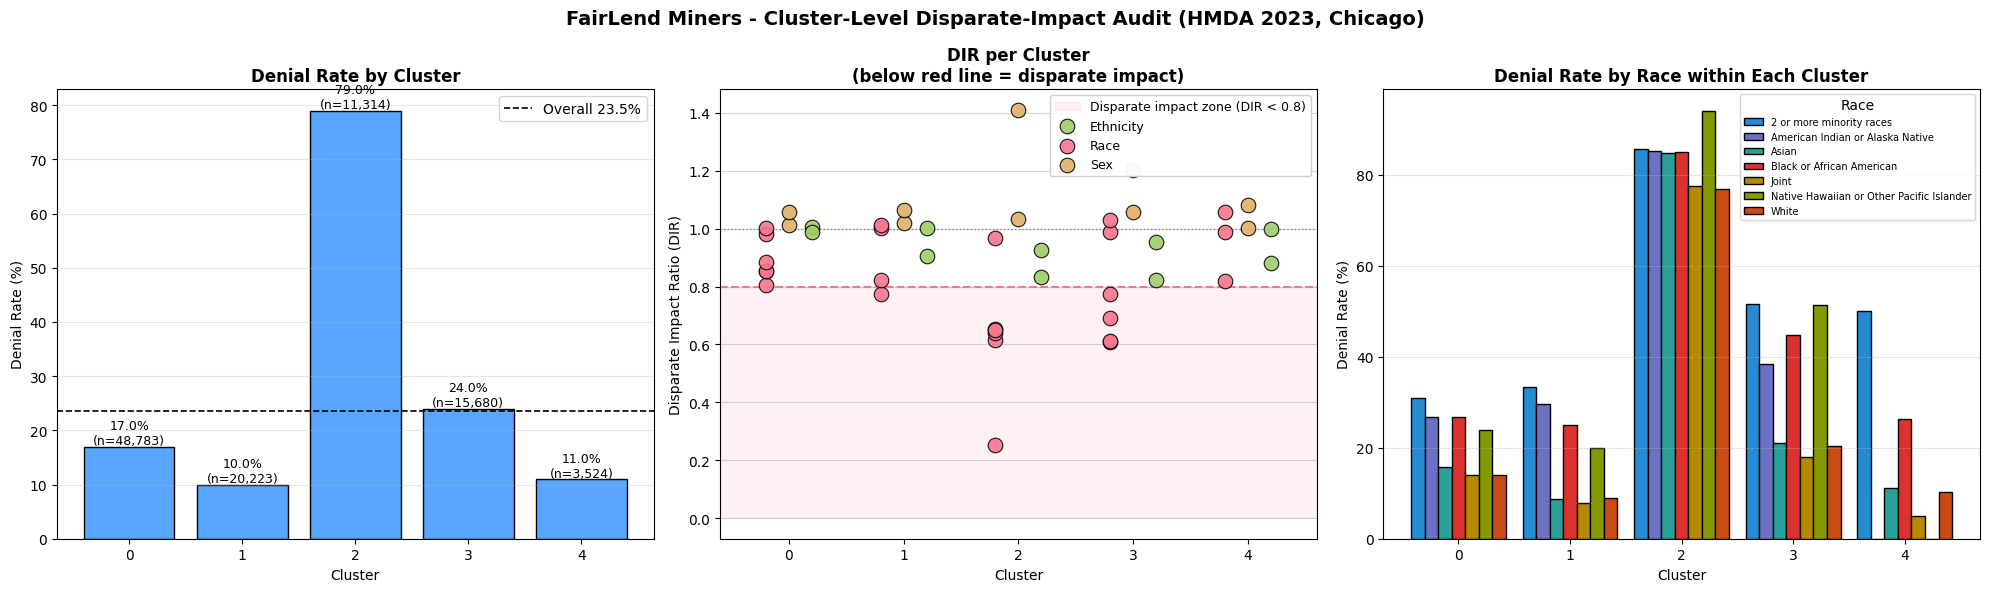

Plot saved: memberC_dir_audit.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('FairLend Miners - Cluster-Level Disparate-Impact Audit (HMDA 2023, Chicago)',
             fontsize=14, fontweight='bold')

# Cluster denial rates
cl = profile.reset_index().sort_values('cluster')
bars = axes[0].bar(cl['cluster'].astype(str), cl['denial_rate%'],
                   color='#58a6ff', edgecolor='black')
axes[0].axhline(model_df['denied_flag'].mean()*100, color='black', ls='--', lw=1.2,
                label=f'Overall {model_df["denied_flag"].mean()*100:.1f}%')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Denial Rate (%)')
axes[0].set_title('Denial Rate by Cluster', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar, val, sz in zip(bars, cl['denial_rate%'], cl['size']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                 f'{val:.1f}%\n(n={sz:,})', ha='center', fontsize=9)

# DIR distribution
if not scoped.empty:
    palette = {'derived_race':'#f7768e',
               'derived_sex':'#e0af68',
               'derived_ethnicity':'#9ece6a'}
    label_map = {'derived_race':'Race',
                 'derived_sex':'Sex',
                 'derived_ethnicity':'Ethnicity'}
    jitter_map = {'derived_race':-0.20,
                  'derived_sex':0.00,
                  'derived_ethnicity':0.20}

    axes[1].axhspan(0, DIR_THRESHOLD, color='#f7768e', alpha=0.10, label=f'Disparate impact zone (DIR < {DIR_THRESHOLD})')
    for attr, sub in scoped.groupby('attribute'):
        x = sub['cluster'].astype(float) + jitter_map.get(attr, 0)
        axes[1].scatter(x, sub['DIR'], label=label_map.get(attr, attr), color=palette.get(attr, '#565f89'), s=110, alpha=0.9, edgecolor='black', linewidth=0.8, zorder=3)

    axes[1].axhline(DIR_THRESHOLD, color='#f7768e', ls='--', lw=1.5, zorder=2)
    axes[1].axhline(1.0, color='#565f89', ls=':', lw=1.0, alpha=0.7, zorder=1)
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('Disparate Impact Ratio (DIR)')
    axes[1].set_title('DIR per Cluster\n(below red line = disparate impact)', fontweight='bold')
    axes[1].set_xticks(sorted(scoped['cluster'].unique()))
    axes[1].set_xlim(-0.6, scoped['cluster'].max() + 0.6)
    axes[1].legend(fontsize=9, loc='upper right', framealpha=0.95)
    axes[1].grid(alpha=0.25, axis='y', color='#565f89')
else:
    axes[1].text(0.5, 0.5, 'No auditable cluster/group pairs',
                 ha='center', va='center', transform=axes[1].transAxes)

# Race denial rate by cluster
race_colors = ['#268bd2','#6c71c4','#2aa198','#dc322f','#b58900','#859900','#cb4b16']
race_pivot = (clustered.groupby(['cluster','derived_race'])['denied_flag'].mean().mul(100).round(1).unstack().fillna(0))
race_pivot.plot(kind='bar', ax=axes[2], width=0.85, edgecolor='black', color=race_colors[:race_pivot.shape[1]])
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Denial Rate (%)')
axes[2].set_title('Denial Rate by Race within Each Cluster', fontweight='bold')
axes[2].legend(fontsize=7, loc='upper right', ncol=1, title='Race')
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/memberC_dir_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: memberC_dir_audit.png')

## 10. Save Outputs

In [17]:
export_cols = [c for c in clustered.columns if c not in ('row_id',)]
clustered[export_cols].to_parquet(CLUSTER_OUT, index=False)
audit_df.to_csv(AUDIT_OUT, index=False)

print(f'Clustered parquet : {CLUSTER_OUT}({os.path.getsize(CLUSTER_OUT)/1024**2:.2f} MB)')
print(f'Audit CSV : {AUDIT_OUT}({len(audit_df):,} rows)')

summary_payload = {
    'best_k' : best_k,
    'k_floor' : K_FLOOR,
    'features' : FEATURES,
    'silhouette_at_best_k': float(metrics_df.loc[metrics_df['k']==best_k,'silhouette'].iloc[0]),
    'wcss_at_best_k' : float(metrics_df.loc[metrics_df['k']==best_k,'wcss'].iloc[0]),
    'rows_clustered' : int(len(clustered)),
    'overall_denial_rate': float(model_df['denied_flag'].mean()),
    'disparate_impact_flags': int((audit_df['flag']=='DISPARATE_IMPACT').sum()),
}
with open(f'{PROJECT_DIR}/memberC_summary.json','w') as f:
    json.dump(summary_payload, f, indent=2)
print(f'Summary JSON : {PROJECT_DIR}/memberC_summary.json')

spark.stop()
print('\nDone.')

Clustered parquet : /content/drive/MyDrive/CS483_Fairlend_Miners/hmda_chicago_2023_clustered.parquet(1.14 MB)
Audit CSV : /content/drive/MyDrive/CS483_Fairlend_Miners/disparate_impact_audit.csv(45 rows)
Summary JSON : /content/drive/MyDrive/CS483_Fairlend_Miners/memberC_summary.json

Done.
